In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
# from tensorflow_addons.losses import SigmoidFocalCrossEntropy
from sklearn.metrics import precision_recall_curve
# Load the dataset
# file_path = "updated_combined_data_with_actual_volume.xlsx"
file_path = "data_without_straw.xlsx"
data = pd.read_excel(file_path)
import random, numpy as np, tensorflow as tf
seed = 42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
# Preprocessing Data
# Convert time to a useful format if necessary and encode labels
data['Label'] = LabelEncoder().fit_transform(data['Label'])

# Assuming each 'Time' captures a snapshot of zones, we can reshape the data
X = data.iloc[:, 1:65].values  # Zone_0 to Zone_63
y = data['Label'].values

# Reshape X for CNN-LSTM, e.g., (samples, time_steps, height, width, channels)
time_steps = 5  # Number of time steps to consider (you can adjust this)
X_seq = []
y_seq = []

for i in range(len(X) - time_steps):
    X_seq.append(X[i:i + time_steps])  # Capture sequential data
    y_seq.append(y[i + time_steps])     # Corresponding label after the sequence ends

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.1, random_state=1,shuffle=True) 
print(y_train)
# Convert labels to category
y_train = to_categorical(y_train, num_classes=2)  # Assuming two classes for drinking
y_test = to_categorical(y_test, num_classes=2)

[1 1 1 ... 1 1 1]


In [2]:
import pandas as pd, numpy as np, random, tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# 0)  Reproducibility
# ------------------------------------------------------------------
seed = 42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

# ------------------------------------------------------------------
# 1)  Load + encode labels
# ------------------------------------------------------------------
file_path = "data_without_straw.xlsx"
data = pd.read_excel(file_path)

le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])     # text → int

X = data.iloc[:, 1:65].values.astype("float32")     # zone features
y = data["Label"].values.astype("int8")             # frame labels

print("Label mapping:")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

# ------------------------------------------------------------------
# 2)  Identify majority / minority *at frame level*
# ------------------------------------------------------------------
from collections import Counter
freq = Counter(y)          # e.g. {0: 18_000, 1: 3_000}
majority_id, minority_id = max(freq, key=freq.get), min(freq, key=freq.get)
print(f"\nMajority label  : {majority_id} ({le.inverse_transform([majority_id])[0]})")
print(f"Minority label  : {minority_id} ({le.inverse_transform([minority_id])[0]})")

# ------------------------------------------------------------------
# 3)  Window generation with class-dependent stride
# ------------------------------------------------------------------
time_steps     = 5          # window length
stride_major   = 17          # skip 4 frames inside majority runs
stride_minor   = 1          # slide by 1 inside minority runs

X_seq, y_seq = [], []
i = 0
while i + time_steps < len(X):
    lbl_next = y[i + time_steps]          # window label = frame at t + time_steps
    X_seq.append(X[i : i + time_steps])
    y_seq.append(lbl_next)

    # advance differently depending on which class we just added
    i += stride_major if lbl_next == majority_id else stride_minor

X_seq = np.asarray(X_seq, dtype="float32")
y_seq = np.asarray(y_seq,  dtype="int8")

# ------------------------------------------------------------------
# 4)  Show the new balance
# ------------------------------------------------------------------
seq_freq = Counter(y_seq)
total_seq = len(y_seq)
print("\nSequence-level distribution AFTER variable stride:")
for k in sorted(seq_freq):
    pct = seq_freq[k] / total_seq * 100
    print(f"  {le.inverse_transform([k])[0]:<15} {seq_freq[k]:>7}  ({pct:.1f} %)")

# ------------------------------------------------------------------
# 5)  Train / test split  +  one-hot labels
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y_seq,
        test_size=0.10,
        random_state=seed,
        stratify=y_seq,           # keep same ratio in both splits
        shuffle=True)

y_train = to_categorical(y_train, num_classes=len(le.classes_))
y_test  = to_categorical(y_test,  num_classes=len(le.classes_))

Label mapping:
  0 → Drinking
  1 → Not_Drinking

Majority label  : 1 (Not_Drinking)
Minority label  : 0 (Drinking)

Sequence-level distribution AFTER variable stride:
  Drinking           3035  (40.1 %)
  Not_Drinking       4532  (59.9 %)


In [3]:
data['Label'].value_counts()

Label
1    74730
0     5345
Name: count, dtype: int64

In [4]:
X_train

array([[[ 305.,  325.,  308., ...,  306.,  316.,  287.],
        [ 305.,  325.,  306., ...,  309.,  316.,  276.],
        [ 305.,  308.,  309., ...,  309.,  316.,  276.],
        [ 309.,  308.,  309., ...,  306.,  310.,  282.],
        [ 309.,  312.,  309., ...,  305.,  312.,  294.]],

       [[ 336.,  261.,  281., ...,  186.,  207.,  254.],
        [ 169.,  188.,  177., ...,  170.,  170.,  193.],
        [ 169.,  188.,  177., ...,  170.,  170.,  193.],
        [ 204.,  202.,  203., ...,  170.,  174.,  193.],
        [ 228.,  217.,  214., ...,  176.,  176.,  202.]],

       [[ 264.,  253.,  275., ...,  202.,  190.,  185.],
        [ 256.,  253.,  253., ...,  201.,  190.,  185.],
        [ 245.,  261.,  277., ...,  201.,  190.,  186.],
        [ 245.,  264.,  251., ...,  202.,  193.,  187.],
        [ 245.,  261.,  251., ...,  203.,  193.,  190.]],

       ...,

       [[ 196.,  186.,  187., ...,  206.,  206.,  209.],
        [ 194.,  186.,  184., ...,  197.,  203.,  212.],
        [ 19

In [5]:
y_train


array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [6]:
np.count_nonzero(y_test == 1)

757

In [7]:
np.count_nonzero(y_train == [1, 0])

5462

In [8]:
labels = np.argmax(y_test, axis=1)          # turns [1,0] -> 0; [0,1] -> 1
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(304), np.int64(1): np.int64(453)}


In [9]:
labels = np.argmax(y_train, axis=1)          # turns [1,0] -> 0; [0,1] -> 1
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(2731), np.int64(1): np.int64(4079)}


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def create_regularised_model(input_shape,
                             weight_decay=5e-5,
                             conv_dropout=0.3,
                             lstm_dropout=0.99):

    L2 = regularizers.l2(weight_decay)
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))               # (T, H, W, C)

    # --- Convolutional feature extractor ---
    for filters in (32, 64, 128):
        model.add(layers.TimeDistributed(
            layers.Conv2D(filters, (3, 3),
                          padding='same',
                          activation='relu',
                          kernel_regularizer=L2)))
        model.add(layers.TimeDistributed(layers.BatchNormalization()))
        model.add(layers.TimeDistributed(layers.MaxPooling2D()))
        # SpatialDropout2D zeroes entire feature maps ➜ stronger regularisation
        model.add(layers.TimeDistributed(layers.SpatialDropout2D(conv_dropout)))

    # Flatten the per-frame feature maps
    model.add(layers.TimeDistributed(layers.Flatten()))

    # --- Temporal modelling with Bi-LSTM ---
    model.add(layers.Bidirectional(
        layers.LSTM(128,
                    return_sequences=True,
                    dropout=lstm_dropout,          # input dropout
                    recurrent_dropout=lstm_dropout, # recurrent dropout
                    kernel_regularizer=L2)))

    # Dropout *between* the two LSTMs
    model.add(layers.Dropout(lstm_dropout))

    model.add(layers.Bidirectional(
        layers.LSTM(64,
                    dropout=lstm_dropout,
                    recurrent_dropout=lstm_dropout,
                    kernel_regularizer=L2)))

    # --- Classification head ---
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=L2))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(2, activation='softmax',
                           kernel_regularizer=L2))

    return model

# Create input shape based on the sequence length and pixel size
input_shape = (time_steps, 8, 8, 1)  # (timesteps, height, width, channels)
model = create_regularised_model(
            input_shape,
            weight_decay=7e-7,   # softer L2
            conv_dropout=0.3,   # weaker SpatialDropout2D
            lstm_dropout=0.10) 
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 8, 8, 32)    │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 8, 8, 32)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 4, 4, 64)    │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 4, 4, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 2, 2, 128)   │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 2, 2, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 1, 1, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 5, 1, 1, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 5, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 529,474 (2.02 MB)

 Trainable params: 529,026 (2.02 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
from sklearn.utils import class_weight
y_train_classes = np.argmax(y_train, axis=1)

class_weights = class_weight.compute_class_weight(
                    class_weight='balanced',
                    classes=np.unique(y_train_classes),
                    y=y_train_classes)
class_weights_dict = dict(enumerate(class_weights))
# Reshape X_train and X_test for CNN input (add channel dimension)
X_train = X_train.reshape(-1, time_steps, 8, 8, 1)
X_test = X_test.reshape(-1, time_steps, 8, 8, 1)
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.15, class_weight=class_weights_dict,callbacks=[early_stopping])
# ,callbacks=[early_stopping]
# Save the model after training
model.save('gesture_recognition_model.h5')

Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7270 - loss: 0.5395 - val_accuracy: 0.8620 - val_loss: 0.3342
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.8480 - loss: 0.3807 - val_accuracy: 0.8748 - val_loss: 0.3327
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8681 - loss: 0.3495 - val_accuracy: 0.8904 - val_loss: 0.3009
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.8857 - loss: 0.3068 - val_accuracy: 0.8826 - val_loss: 0.3034


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# p_val = model.predict(X_test, verbose=0)[:, 0]     # P(Not-Drinking)
# y_val_bin = np.argmax(y_test, axis=1)              # 0 / 1 labels

# prec, rec, thr = precision_recall_curve(y_val_bin, p_val)
# f1   = 2*prec*rec / (prec+rec+1e-9)
# best = np.argmax(f1)
# best_thr = thr[best]
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict labels for the test set
y_pred = model.predict(X_test)
print(y_pred)


# p_test  = model.predict(X_test, verbose=0)[:, 0]   # P(Not-Drinking)

# nd_pred = (p_test > best_thr).astype(int)          # raw 0/1 labels

# # >>> ADD THE FILTER HERE <<<
# import scipy.signal as sg
# nd_pred = sg.medfilt(nd_pred, kernel_size=9)       # smooth isolated frames

# # rebuild the 2-column one-hot matrix if you need it
# dr_pred = 1 - nd_pred
# y_pred  = np.stack([nd_pred, dr_pred], axis=1)







y_pred_classes = np.argmax(y_pred, axis=1)  # Get class labels from probabilities

y_true_classes = np.argmax(y_test, axis=1)  # True labels

# Classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=["Drinking", "Not Drinking"]))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8800 - loss: 0.2920
Test Accuracy: 0.8956
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
[[0.8504664  0.14953367]
 [0.02779332 0.9722068 ]
 [0.9462292  0.05377071]
 ...
 [0.8062293  0.19377081]
 [0.13177754 0.8682224 ]
 [0.03287508 0.967125  ]]
              precision    recall  f1-score   support

    Drinking       0.83      0.93      0.88       304
Not Drinking       0.95      0.87      0.91       453

    accuracy                           0.90       757
   macro avg       0.89      0.90      0.89       757
weighted avg       0.90      0.90      0.90       757



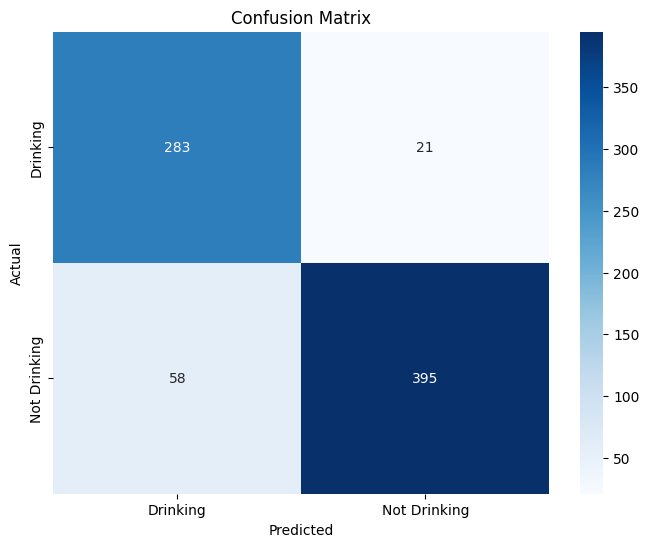

In [13]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Drinking", "Not Drinking"], yticklabels=["Drinking", "Not Drinking"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# If you have a regression model for Actual Volume, replace the following
# with y_true_volume and y_pred_volume definitions as appropriate.

# Assuming you have y_true_volume and y_pred_volume
from sklearn.metrics import mean_squared_error

# Replace with actual volume predictions when regression model is created
# y_pred_volume will typically be obtained from your regression model
# y_true_volume should be the true values from the dataset
y_true_volume = data['Actual_Volume'].values  # Use your actual volumes for regression

# Predict volumes using your regression model (e.g., predict_model) if it's separate
# This is just a placeholder for where to put your actual volume predictions
# y_pred_volume = regression_model.predict(X_volume)

# Example MSE and RMSE calculation
mse = mean_squared_error(y_true_volume, y_pred_volume)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

NameError: name 'y_pred_volume' is not defined

In [ ]:
import numpy as np
import pandas as pd

# ---- 1.  Frame-level balance -----------------------------------
frame_counts = pd.Series(y).value_counts().sort_index()
print("Frame-level labels")
print(frame_counts.rename(index={0: "Not-Drinking", 1: "Drinking"}))
print()

# ---- 2.  Sequence-level balance (after the sliding window) -----
seq_counts = pd.Series(y_seq).value_counts().sort_index()
print("Sequence-level labels (y_seq)")
print(seq_counts.rename(index={0: "Not-Drinking", 1: "Drinking"}))

# ---- 3.  Quick percentages -------------------------------------
pct = (seq_counts / seq_counts.sum() * 100).round(1)
print(f"\nSequence-level ratio: {pct[0]} % Not-Drinking  /  {pct[1]} % Drinking")